
# 07. 물어보기: 사다리 2단계 "스스로 공부하기" 졸업 시험

**질문**: 시스템이 모르는 걸 안다는 걸 알고, 필요할 때 **누구에게 물을지** 스스로 정할 수 있을까?

**세계**: 말투 세계에서, 문제마다 한 사람에게 한 번 물어볼 수 있다. 물으면 그 문제 점수에서 **0.2를 뺀다**.
- 그 문에 대해 아직 말 안 한 사람은 새 말을 한다(그 사람의 실력대로, 말투도 붙는다).
- 이미 말한 사람은 새로 할 말이 없다. 비용만 날린다.

**시스템**: 1단계 시스템(읽기, 연결, 기억, 판단)은 **얼리고**, 새 부품 **호기심 머리**(파라미터 10,689개)만 붙였다.
- 호기심 머리는 "이 사람에게 물으면 점수가 얼마나 오를까"를 예측한다.
- 예측값이 비용보다 크면 묻는다.
- 정답 행동을 가르친 적은 없고, 물어본 결과로만 배웠다.

| 비교 | 설명 |
|---|---|
| 안 물음 | 1단계 그대로 |
| 손 규칙 | 모르겠으면(답하지 않을 상황이면), 아직 안 말한 사람 아무에게나 묻는다 |
| **호기심 머리** | 언제, 누구에게 물을지 스스로 정한다 |
| 이상적 베이즈 (점선) | 세계 규칙을 다 알고 정보 가치를 정확히 계산하는 기준선 |

**졸업 기준(결과 보기 전에 정함)**: 시드 3개 모두 손 규칙보다 높고 평균 +0.03 이상. 그리고 "안 물음" 대비 이득이 이상적 베이즈 이득의 절반 이상.


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()
SEEDS = (42, 43, 44)
runs = {s: json.loads((S.RESULTS / f"world-v2a_curiosity_cost-0.2_seed-{s}.json").read_text(encoding="utf-8")) for s in SEEDS}
whom = json.loads((S.RESULTS / "world-v2a_curiosity_whom.json").read_text(encoding="utf-8"))

vs_hand = [runs[s]["test"]["curiosity"]["net"] - runs[s]["test"]["hand-rule"]["net"] for s in SEEDS]
vs_never = [runs[s]["test"]["curiosity"]["net"] - runs[s]["test"]["never"]["net"] for s in SEEDS]
ideal_gain = [runs[s]["ideal_bayes_with_cues"]["voi"]["net"] - runs[s]["ideal_bayes_with_cues"]["never"]["net"] for s in SEEDS]
m, h = S.mean_ci(vs_hand)
print("손 규칙 대비:", [round(v, 4) for v in vs_hand], f"평균 {m:+.3f} [{m - h:+.3f}, {m + h:+.3f}]")
print("안 물음 대비:", [round(v, 3) for v in vs_never], " 이상적 베이즈의 이득:", [round(v, 3) for v in ideal_gain])
ok = all(v > 0 for v in vs_hand) and m >= 0.03 and all(a >= 0.5 * b for a, b in zip(vs_never, ideal_gain))
print("졸업" if ok else "미달")


손 규칙 대비: [0.0668, 0.1031, 0.0762] 평균 +0.082 [+0.035, +0.129]
안 물음 대비: [0.116, 0.151, 0.146]  이상적 베이즈의 이득: [0.111, 0.148, 0.141]
졸업



## 1. 점수 (비용을 뺀 점수)


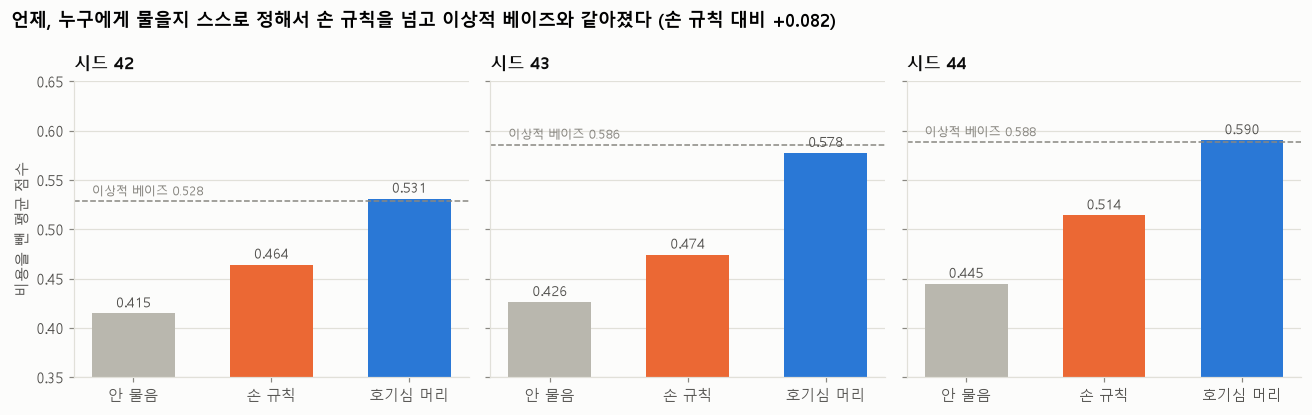

In [2]:

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
policies = [("안 물음", "never", V.NEUTRAL), ("손 규칙", "hand-rule", V.ORANGE), ("호기심 머리", "curiosity", V.BLUE)]
for ax, seed in zip(axes, SEEDS):
    r = runs[seed]
    for i, (label, key, color) in enumerate(policies):
        v = r["test"][key]["net"]
        ax.bar(i, v, width=0.6, color=color)
        ax.text(i, v + 0.006, f"{v:.3f}", ha="center", fontsize=9, color=V.TEXT_SECONDARY)
    ideal = r["ideal_bayes_with_cues"]["voi"]["net"]
    ax.axhline(ideal, color=V.MUTED, linestyle="--", linewidth=1)
    ax.text(-0.3, ideal + 0.006, f"이상적 베이즈 {ideal:.3f}", ha="left", fontsize=8, color=V.MUTED)
    ax.set_xticks(range(3), [p[0] for p in policies])
    ax.set_ylim(0.35, 0.65)
    ax.grid(axis="x", visible=False)
    ax.set_title(f"시드 {seed}", fontsize=11, pad=8)
axes[0].set_ylabel("비용을 뺀 평균 점수")
fig.suptitle(f"언제, 누구에게 물을지 스스로 정해서 손 규칙을 넘고 이상적 베이즈와 같아졌다 (손 규칙 대비 +{m:.3f})",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()



## 2. 누구에게 묻나

물어볼 수 있는 사람(그 문에 대해 아직 말 안 한 사람)을 숨은 정확도별로 나누고, 실제로 물어본 비율을 셌다. 시스템은 정확도를 모른다. 피드백으로 쌓은 기억만으로 고른다.


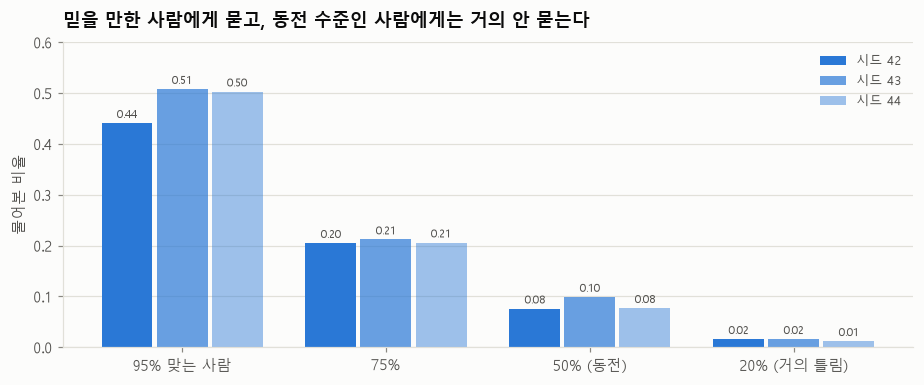

In [3]:

levels = ["0.95", "0.75", "0.5", "0.2"]
labels = ["95% 맞는 사람", "75%", "50% (동전)", "20% (거의 틀림)"]
fig, ax = plt.subplots(figsize=(8.5, 3.6))
x = np.arange(len(levels))
width = 0.25
for i, seed in enumerate(SEEDS):
    values = [whom[str(seed)][l]["ask_rate"] for l in levels]
    ax.bar(x + (i - 1) * (width + 0.02), values, width=width, color=V.BLUE, alpha=[1.0, 0.7, 0.45][i], label=f"시드 {seed}")
    for xi, v in zip(x, values):
        ax.text(xi + (i - 1) * (width + 0.02), v + 0.01, f"{v:.2f}", ha="center", fontsize=7.5, color=V.TEXT_SECONDARY)
ax.set_xticks(x, labels)
ax.set_ylim(0, 0.6)
ax.grid(axis="x", visible=False)
ax.set_ylabel("물어본 비율")
ax.legend(fontsize=8.5, frameon=False)
ax.set_title("믿을 만한 사람에게 묻고, 동전 수준인 사람에게는 거의 안 묻는다", pad=10)
fig.tight_layout()
plt.show()



- 20% 사람은 "거꾸로" 정보를 주긴 한다(그 사람이 말한 열쇠는 아마 아니다). 하지만 남는 후보가 2개라 정보가 약하고, 비용 0.2를 넘지 못한다. 그래서 안 묻는 게 맞다.
- 이미 말한 사람에게 물어서 비용을 날린 경우는 **0%**였다(시드 3개 모두).

## 3. 정리

- **2단계 졸업.** 손 규칙 대비 +0.067, +0.103, +0.076이고, 평균 **+0.082**, 95% 신뢰구간은 [+0.035, +0.129]다.
- "안 물음" 대비 이득(+0.116, +0.151, +0.146)이 이상적 베이즈의 이득(+0.111, +0.148, +0.141)과 같은 수준이다.
- 정답 행동을 가르치지 않았다. "물어봤더니 점수가 얼마나 올랐나"만 보고 **언제 모르는지, 누가 믿을 만한지, 이미 말한 사람에게는 물을 필요 없다는 것**을 함께 배웠다.
- 새로 학습한 부품은 호기심 머리 10,689개뿐이고, 1단계 시스템은 그대로 얼렸다. 시드 하나에 약 1–1.5분 걸렸다.
- 한계: 비용 0.2 하나, 한 번만 묻기, 당장 이득만 본다(나중을 위한 탐색은 없다). 이상적 베이즈도 같은 조건이다.
